In [12]:
%pip install pandas scikit-learn numpy
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   -


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Shape: (4803, 7)
       id                                     title  \
0   19995                                    Avatar   
1     285  Pirates of the Caribbean: At World's End   
2  206647                                   Spectre   

                                            overview  \
0  In the 22nd century, a paraplegic Marine is di...   
1  Captain Barbossa, long believed to be dead, ha...   
2  A cryptic message from Bond’s past sends him o...   

                                              genres  \
0  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                            keywords  vote_average  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...           7.2   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...           6.9   
2  [{"id": 470, "name": "spy"}, {"id": 818, "name...           6.3   

  release_date  
0   2009-12-10

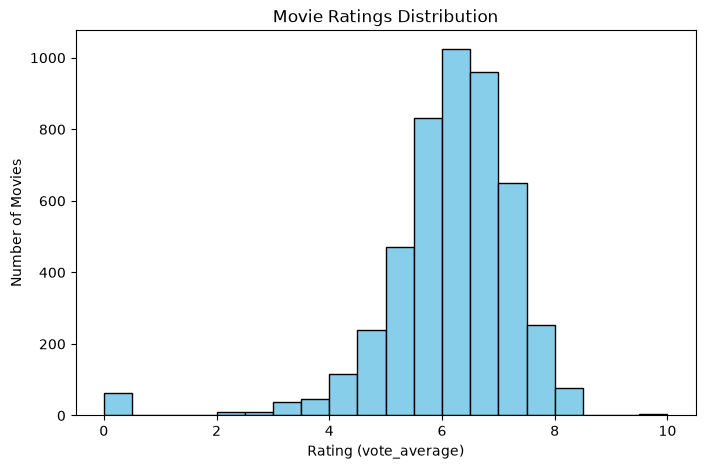

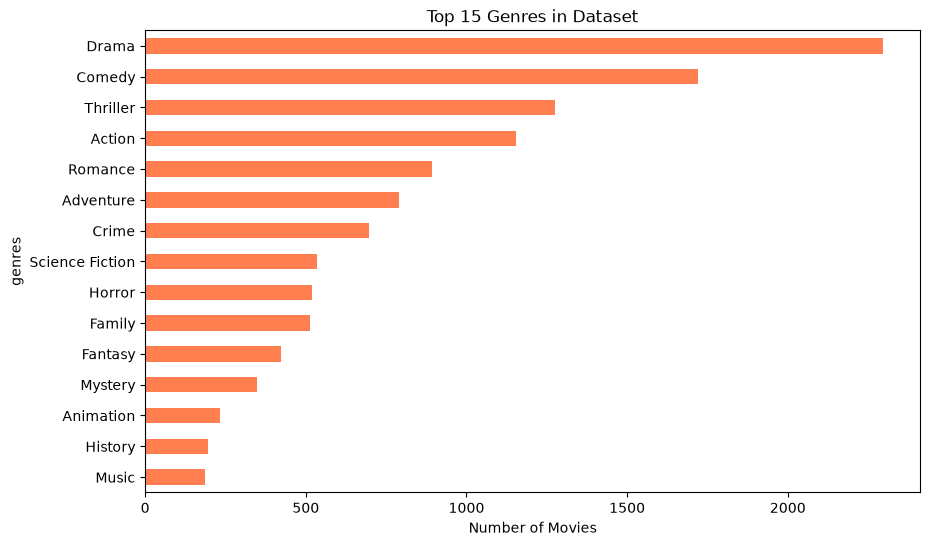

Missing tags: 0
In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. Action Adventure Fantasy ScienceFiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d
TF-IDF matrix shape: (4802, 5000)
Similarity dtype: float32
Similarity matrix shape: (4802, 4802)
[1.         0.02445175 0.01344362 0.02214813 0.1039448 ]
['Falcon Rising', 'Battle: Los Angeles', 'Apollo 18', 'Titan A.E.', 'Predators']
['The Dark Knight Rises', 'Batman Returns', 'Batman Begins', 'Batman Forever', 'Batman: The Dark Knight Returns, Part 2']
['Raise the Titanic', 'Poseidon', 'Ghost Ship', 'In the Heart of the Sea', 'Captain Phillips']
Sab kuch save ho gaya!


In [26]:
# ============================================
# STEP 0: Imports
# ============================================
import pandas as pd
import ast
import pickle
import os


# ============================================
# STEP 2-3: Load & Understand Data
# ============================================
movies = pd.read_csv('tmdb_5000_movies.csv')

movies = movies[['id', 'title', 'overview', 'genres', 'keywords', 'vote_average', 'release_date']]

print("Shape:", movies.shape)
print(movies.head(3))
print(movies.info())
print(movies.describe())


# ============================================
# STEP 4: Data Cleaning
# ============================================

# Missing overview ko empty string bana do
movies['overview'] = movies['overview'].fillna('')

# Missing release_date wali row hata do (sirf 1 thi)
movies = movies.dropna(subset=['release_date'])

print("Cleaned shape:", movies.shape)

# Duplicates check
print("Duplicate rows:", movies.duplicated().sum())
print("Duplicate titles:", movies['title'].duplicated().sum())


# ============================================
# STEP 5: EDA (optional graphs — skip if just running pipeline)
# ============================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(movies['vote_average'], bins=20, color='skyblue', edgecolor='black')
plt.title('Movie Ratings Distribution')
plt.xlabel('Rating (vote_average)')
plt.ylabel('Number of Movies')
plt.show()

def get_genre_names(text):
    items = ast.literal_eval(text)
    return [i['name'] for i in items]

all_genres = movies['genres'].apply(get_genre_names).explode()
genre_counts = all_genres.value_counts().head(15)

plt.figure(figsize=(10, 6))
genre_counts.plot(kind='barh', color='coral')
plt.title('Top 15 Genres in Dataset')
plt.xlabel('Number of Movies')
plt.gca().invert_yaxis()
plt.show()


# ============================================
# STEP 6: Data Preprocessing — Build 'tags' + TF-IDF
# ============================================

def extract_names(text):
    items = ast.literal_eval(text)
    names = [item['name'].replace(" ", "") for item in items]
    return " ".join(names)

movies['genres_clean'] = movies['genres'].apply(extract_names)
movies['keywords_clean'] = movies['keywords'].apply(extract_names)

# Combine everything into one tags column
movies['tags'] = movies['overview'] + " " + movies['genres_clean'] + " " + movies['keywords_clean']

print("Missing tags:", movies['tags'].isnull().sum())
print(movies['tags'].iloc[0])

# TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(movies['tags'])

print("TF-IDF matrix shape:", tfidf_matrix.shape)


# ============================================
# STEP 7: Cosine Similarity (float32 — chhoti file size ke liye)
# ============================================
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(tfidf_matrix).astype('float32')

print("Similarity dtype:", similarity.dtype)
print("Similarity matrix shape:", similarity.shape)
print(similarity[0][:5])  # pehli movie ki pehli 5 movies se similarity


# ============================================
# STEP 8: Recommendation Function + Test
# ============================================
def recommend(movie_title, top_n=5):
    matches = movies[movies['title'].str.lower() == movie_title.lower()]

    if matches.empty:
        return f"Movie '{movie_title}' dataset mein nahi mili."

    idx = matches.index[0]

    sim_scores = list(enumerate(similarity[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]
    return movies['title'].iloc[movie_indices].tolist()


print(recommend("Avatar"))
print(recommend("The Dark Knight"))
print(recommend("Titanic"))


# ============================================
# STEP 9: Save Model Files (ek hi jagah, final version)
# ============================================
os.makedirs('model', exist_ok=True)

with open('model/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

with open('model/similarity.pkl', 'wb') as f:
    pickle.dump(similarity, f)

movies.to_pickle('model/movies.pkl')

print("Sab kuch save ho gaya!")